In [168]:
print("Hello, World!")

Hello, World!


In [169]:
import sys

print(sys.version)

3.12.3 (v3.12.3:f6650f9ad7, Apr  9 2024, 08:18:47) [Clang 13.0.0 (clang-1300.0.29.30)]


In [170]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
df = pd.read_parquet('green_tripdata_2021-01.parquet')

In [172]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


In [173]:
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

In [174]:
df = df[(df.duration >= 1) & (df.duration <= 45)]



In [175]:
df.isnull().sum()

VendorID                     0
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       34395
RatecodeID               34395
PULocationID                 0
DOLocationID                 0
passenger_count          34395
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                71627
improvement_surcharge        0
total_amount                 0
payment_type             34395
trip_type                34395
congestion_surcharge     34395
duration                     0
dtype: int64

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71627 entries, 0 to 76517
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               71627 non-null  int64         
 1   lpep_pickup_datetime   71627 non-null  datetime64[us]
 2   lpep_dropoff_datetime  71627 non-null  datetime64[us]
 3   store_and_fwd_flag     37232 non-null  object        
 4   RatecodeID             37232 non-null  float64       
 5   PULocationID           71627 non-null  int64         
 6   DOLocationID           71627 non-null  int64         
 7   passenger_count        37232 non-null  float64       
 8   trip_distance          71627 non-null  float64       
 9   fare_amount            71627 non-null  float64       
 10  extra                  71627 non-null  float64       
 11  mta_tax                71627 non-null  float64       
 12  tip_amount             71627 non-null  float64       
 13  tolls_

In [177]:
numerical = [ 'trip_distance', 'fare_amount', 'total_amount']
categorical = ['RatecodeID', 'PULocationID', 'DOLocationID']

df[categorical] = df[categorical].astype(str)


In [178]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.impute import SimpleImputer

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [179]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [180]:
y_train = df.duration.values

In [181]:
model = LinearRegression()
model_2 = Lasso()
model.fit(X_train, y_train)
model_2.fit(X_train, y_train)

y_pred = model.predict(X_train)
y_pred_2 = model_2.predict(X_train)

error_1 = root_mean_squared_error(y_train, y_pred)
error_2 = mean_absolute_error(y_train, y_pred)

error_1_2 = root_mean_squared_error(y_train, y_pred_2)
error_2_2 = mean_absolute_error(y_train, y_pred_2)

print(f'RMSE_1: {error_1:.2f}')
print(f'MAE_1: {error_2:.2f}')

print(f'RMSE_2: {error_1_2:.2f}')
print(f'MAE_2: {error_2_2:.2f}')



 

RMSE_1: 5.75
MAE_1: 4.03
RMSE_2: 6.18
MAE_2: 4.46


/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_29303/1505421196.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_29303/1505421196.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, lab

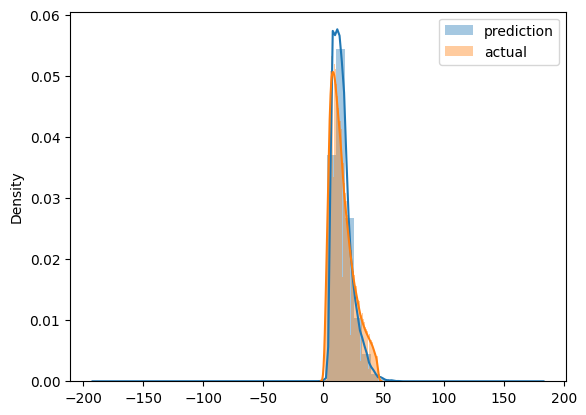

In [182]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
plt.legend()

Now to test on validation set

In [189]:
df_val = pd.read_parquet('green_tripdata_2021-02.parquet')


In [190]:
categorical = ['PULocationID', 'DOLocationID'] 
numerical = [ 'trip_distance', 'fare_amount', 'total_amount']


In [191]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [192]:
df_val.lpep_dropoff_datetime = pd.to_datetime(df_val.lpep_dropoff_datetime)
df_val.lpep_pickup_datetime = pd.to_datetime(df_val.lpep_pickup_datetime)

df_val['duration'] = df_val.lpep_dropoff_datetime - df_val.lpep_pickup_datetime
df_val.duration = df_val.duration.apply(lambda td: td.total_seconds()/ 60)

In [193]:
target = 'duration'
df_val.duration = df_val.duration.fillna(df.duration.median())
y_train = df[target].values
y_val = df_val[target].values

In [195]:
lr = LinearRegression()
lr.fit(X_train, y_train)

ll= Lasso(0.01)
ll.fit(X_train, y_train)

y_pred = lr.predict(X_val)
y_pred_2 = ll.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)

mae_2 = mean_absolute_error(y_val, y_pred_2)

print(f'MAE: {mae:.2f}')
print(f'MAE_2: {mae_2:.2f}')


MAE: 8.63
MAE_2: 8.15


/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_29303/2624495092.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_29303/2624495092.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_val, label

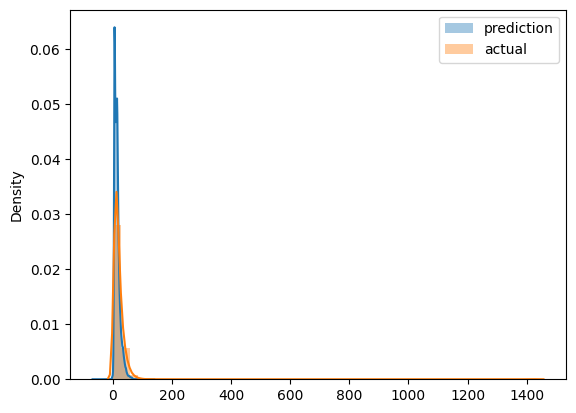

In [197]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_val, label='actual')

plt.legend()